In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygmt
import pandas as pd
import geopandas as gpd
import glob
from shapely.geometry import Point, box

## 測速照相資料

In [2]:
filename = './stations/NPA_TD1_114.csv'
df = pd.read_csv(filename, sep= ',', header = 0, skipinitialspace=True)
df = pd.DataFrame(df[1:])
df.reset_index(inplace=True, drop = True)
df['limit'] = df['limit'].astype('int').copy()
df

,CityName,RegionName,Address,DeptNm,BranchNm,Longitude,Latitude,direct,limit
0,連江縣,南竿鄉,介壽村47-10號前,連江縣警察局,南竿警察所,119.95137,26.160198,順向(往介壽村方向),30
1,連江縣,北竿鄉,塘岐村168號前,連江縣警察局,北竿警察所,119.99763,26.223022,順向(往機場方向),30
2,連江縣,北竿鄉,板里村46號前,連江縣警察局,北竿警察所,119.97415,26.216692,順向(往白沙方向),30
3,金門縣,金城鎮,西海路水頭路段,金門縣警察局,金城分局,118.29999,24.411718,東西雙向,50
4,金門縣,金城鎮,環島南路小西門路段,金門縣警察局,金城分局,118.32414,24.413134,東西雙向,60
...,...,...,...,...,...,...,...,...,...
2518,國道3甲,NaN,國道三甲西向1.7公里,國道公路警察局,國道公路警九隊,121.56336,25.010769,往西,80
2519,國道3甲,NaN,國道三甲西向3.4公里,國道公路警察局,國道公路警九隊,121.57856,25.005106,往西,80
2520,國道3甲,NaN,國道三號甲線西向1.7公里,國道公路警察局,國道公路警九隊,121.56336,25.010769,往西,80
2521,國道3甲,NaN,國道三號甲線西向3.4公里,國道公路警察局,國道公路警九隊,121.57856,25.005106,往西,80


## 縣市範圍資料

In [3]:
path = glob.glob('./data/*.shp')

gdf = gpd.read_file(path[1], encoding='utf-8')
#by gemini
if gdf.crs.to_string() != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

gdf =gdf.sort_values(by='TOWNID')
gdf.reset_index(drop = True,inplace = True)
# 選項：如果你只想畫特定城市 (例如：只畫台北市)
# 假設欄位名稱是 'COUNTYNAME' (依實際檔案而定)
# 如果要畫所有縣市，就直接放 gdf
gdf

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,A01,63000010,臺北市,松山區,Songshan District,A,63000,"POLYGON ((121.572 25.07263, 121.57206 25.07224..."
1,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044..."
2,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048..."
3,A05,63000070,臺北市,萬華區,Wanhua District,A,63000,"POLYGON ((121.50899 25.04829, 121.50945 25.048..."
4,A09,63000060,臺北市,大同區,Datong District,A,63000,"POLYGON ((121.51354 25.08079, 121.51411 25.079..."
...,...,...,...,...,...,...,...,...
363,X06,10016060,澎湖縣,七美鄉,Qimei Township,X,10016,"POLYGON ((119.44026 23.22137, 119.44041 23.221..."
364,Z01,09007010,連江縣,南竿鄉,Nangan Township,Z,09007,"MULTIPOLYGON (((119.95789 26.08099, 119.95784 ..."
365,Z02,09007020,連江縣,北竿鄉,Beigan Township,Z,09007,"MULTIPOLYGON (((119.98075 26.18671, 119.98066 ..."
366,Z03,09007030,連江縣,莒光鄉,Juguang Township,Z,09007,"MULTIPOLYGON (((119.96446 25.94552, 119.96428 ..."


In [4]:
taipei = gdf[gdf['COUNTYNAME'] == '臺北市'].copy()
taipei

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,A01,63000010,臺北市,松山區,Songshan District,A,63000,"POLYGON ((121.572 25.07263, 121.57206 25.07224..."
1,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044..."
2,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048..."
3,A05,63000070,臺北市,萬華區,Wanhua District,A,63000,"POLYGON ((121.50899 25.04829, 121.50945 25.048..."
4,A09,63000060,臺北市,大同區,Datong District,A,63000,"POLYGON ((121.51354 25.08079, 121.51411 25.079..."
5,A10,63000040,臺北市,中山區,Zhongshan District,A,63000,"POLYGON ((121.54232 25.09184, 121.5425 25.0917..."
6,A11,63000080,臺北市,文山區,Wenshan District,A,63000,"POLYGON ((121.59711 25.0146, 121.59721 25.0144..."
7,A13,63000090,臺北市,南港區,Nangang District,A,63000,"POLYGON ((121.6223 25.05891, 121.62234 25.0588..."
8,A14,63000100,臺北市,內湖區,Neihu District,A,63000,"POLYGON ((121.59431 25.11454, 121.59438 25.114..."
9,A15,63000110,臺北市,士林區,Shilin District,A,63000,"POLYGON ((121.58102 25.19533, 121.58118 25.195..."


## 計算行政區包含測速照相數

In [5]:
df_count = gpd.GeoDataFrame(df.copy(),
                            geometry=gpd.points_from_xy(df.copy().Longitude,
                                                        df.copy().Latitude),
                            crs="EPSG:4326" # 指定這是經緯度格式
)
joined = gpd.sjoin(taipei, df_count, how="left", predicate="contains") #by gemini 3
# 假設 joined_gdf 是你做完 sjoin 的結果
# 'CTYNAME' 是你的行政區名稱欄位
counts = joined.groupby(joined.index)['index_right'].count()
taipei['point_count'] = counts
taipei

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry,point_count
0,A01,63000010,臺北市,松山區,Songshan District,A,63000,"POLYGON ((121.572 25.07263, 121.57206 25.07224...",5
1,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044...",12
2,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048...",4
3,A05,63000070,臺北市,萬華區,Wanhua District,A,63000,"POLYGON ((121.50899 25.04829, 121.50945 25.048...",5
4,A09,63000060,臺北市,大同區,Datong District,A,63000,"POLYGON ((121.51354 25.08079, 121.51411 25.079...",1
5,A10,63000040,臺北市,中山區,Zhongshan District,A,63000,"POLYGON ((121.54232 25.09184, 121.5425 25.0917...",10
6,A11,63000080,臺北市,文山區,Wenshan District,A,63000,"POLYGON ((121.59711 25.0146, 121.59721 25.0144...",14
7,A13,63000090,臺北市,南港區,Nangang District,A,63000,"POLYGON ((121.6223 25.05891, 121.62234 25.0588...",8
8,A14,63000100,臺北市,內湖區,Neihu District,A,63000,"POLYGON ((121.59431 25.11454, 121.59438 25.114...",12
9,A15,63000110,臺北市,士林區,Shilin District,A,63000,"POLYGON ((121.58102 25.19533, 121.58118 25.195...",8


In [6]:
taipei['CBC'] = taipei.groupby(taipei.COUNTYID)['point_count'].transform('sum').copy()
taipei

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry,point_count,CBC
0,A01,63000010,臺北市,松山區,Songshan District,A,63000,"POLYGON ((121.572 25.07263, 121.57206 25.07224...",5,92
1,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044...",12,92
2,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048...",4,92
3,A05,63000070,臺北市,萬華區,Wanhua District,A,63000,"POLYGON ((121.50899 25.04829, 121.50945 25.048...",5,92
4,A09,63000060,臺北市,大同區,Datong District,A,63000,"POLYGON ((121.51354 25.08079, 121.51411 25.079...",1,92
5,A10,63000040,臺北市,中山區,Zhongshan District,A,63000,"POLYGON ((121.54232 25.09184, 121.5425 25.0917...",10,92
6,A11,63000080,臺北市,文山區,Wenshan District,A,63000,"POLYGON ((121.59711 25.0146, 121.59721 25.0144...",14,92
7,A13,63000090,臺北市,南港區,Nangang District,A,63000,"POLYGON ((121.6223 25.05891, 121.62234 25.0588...",8,92
8,A14,63000100,臺北市,內湖區,Neihu District,A,63000,"POLYGON ((121.59431 25.11454, 121.59438 25.114...",12,92
9,A15,63000110,臺北市,士林區,Shilin District,A,63000,"POLYGON ((121.58102 25.19533, 121.58118 25.195...",8,92


basemap [INFORMATION]: Constructing the basemap
basemap [INFORMATION]: Central meridian not given, default to 121.55
basemap [INFORMATION]: Map scale is 2.56891 km per cm or 1:256891.
basemap [INFORMATION]: Save current gridline information to gmt.history
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

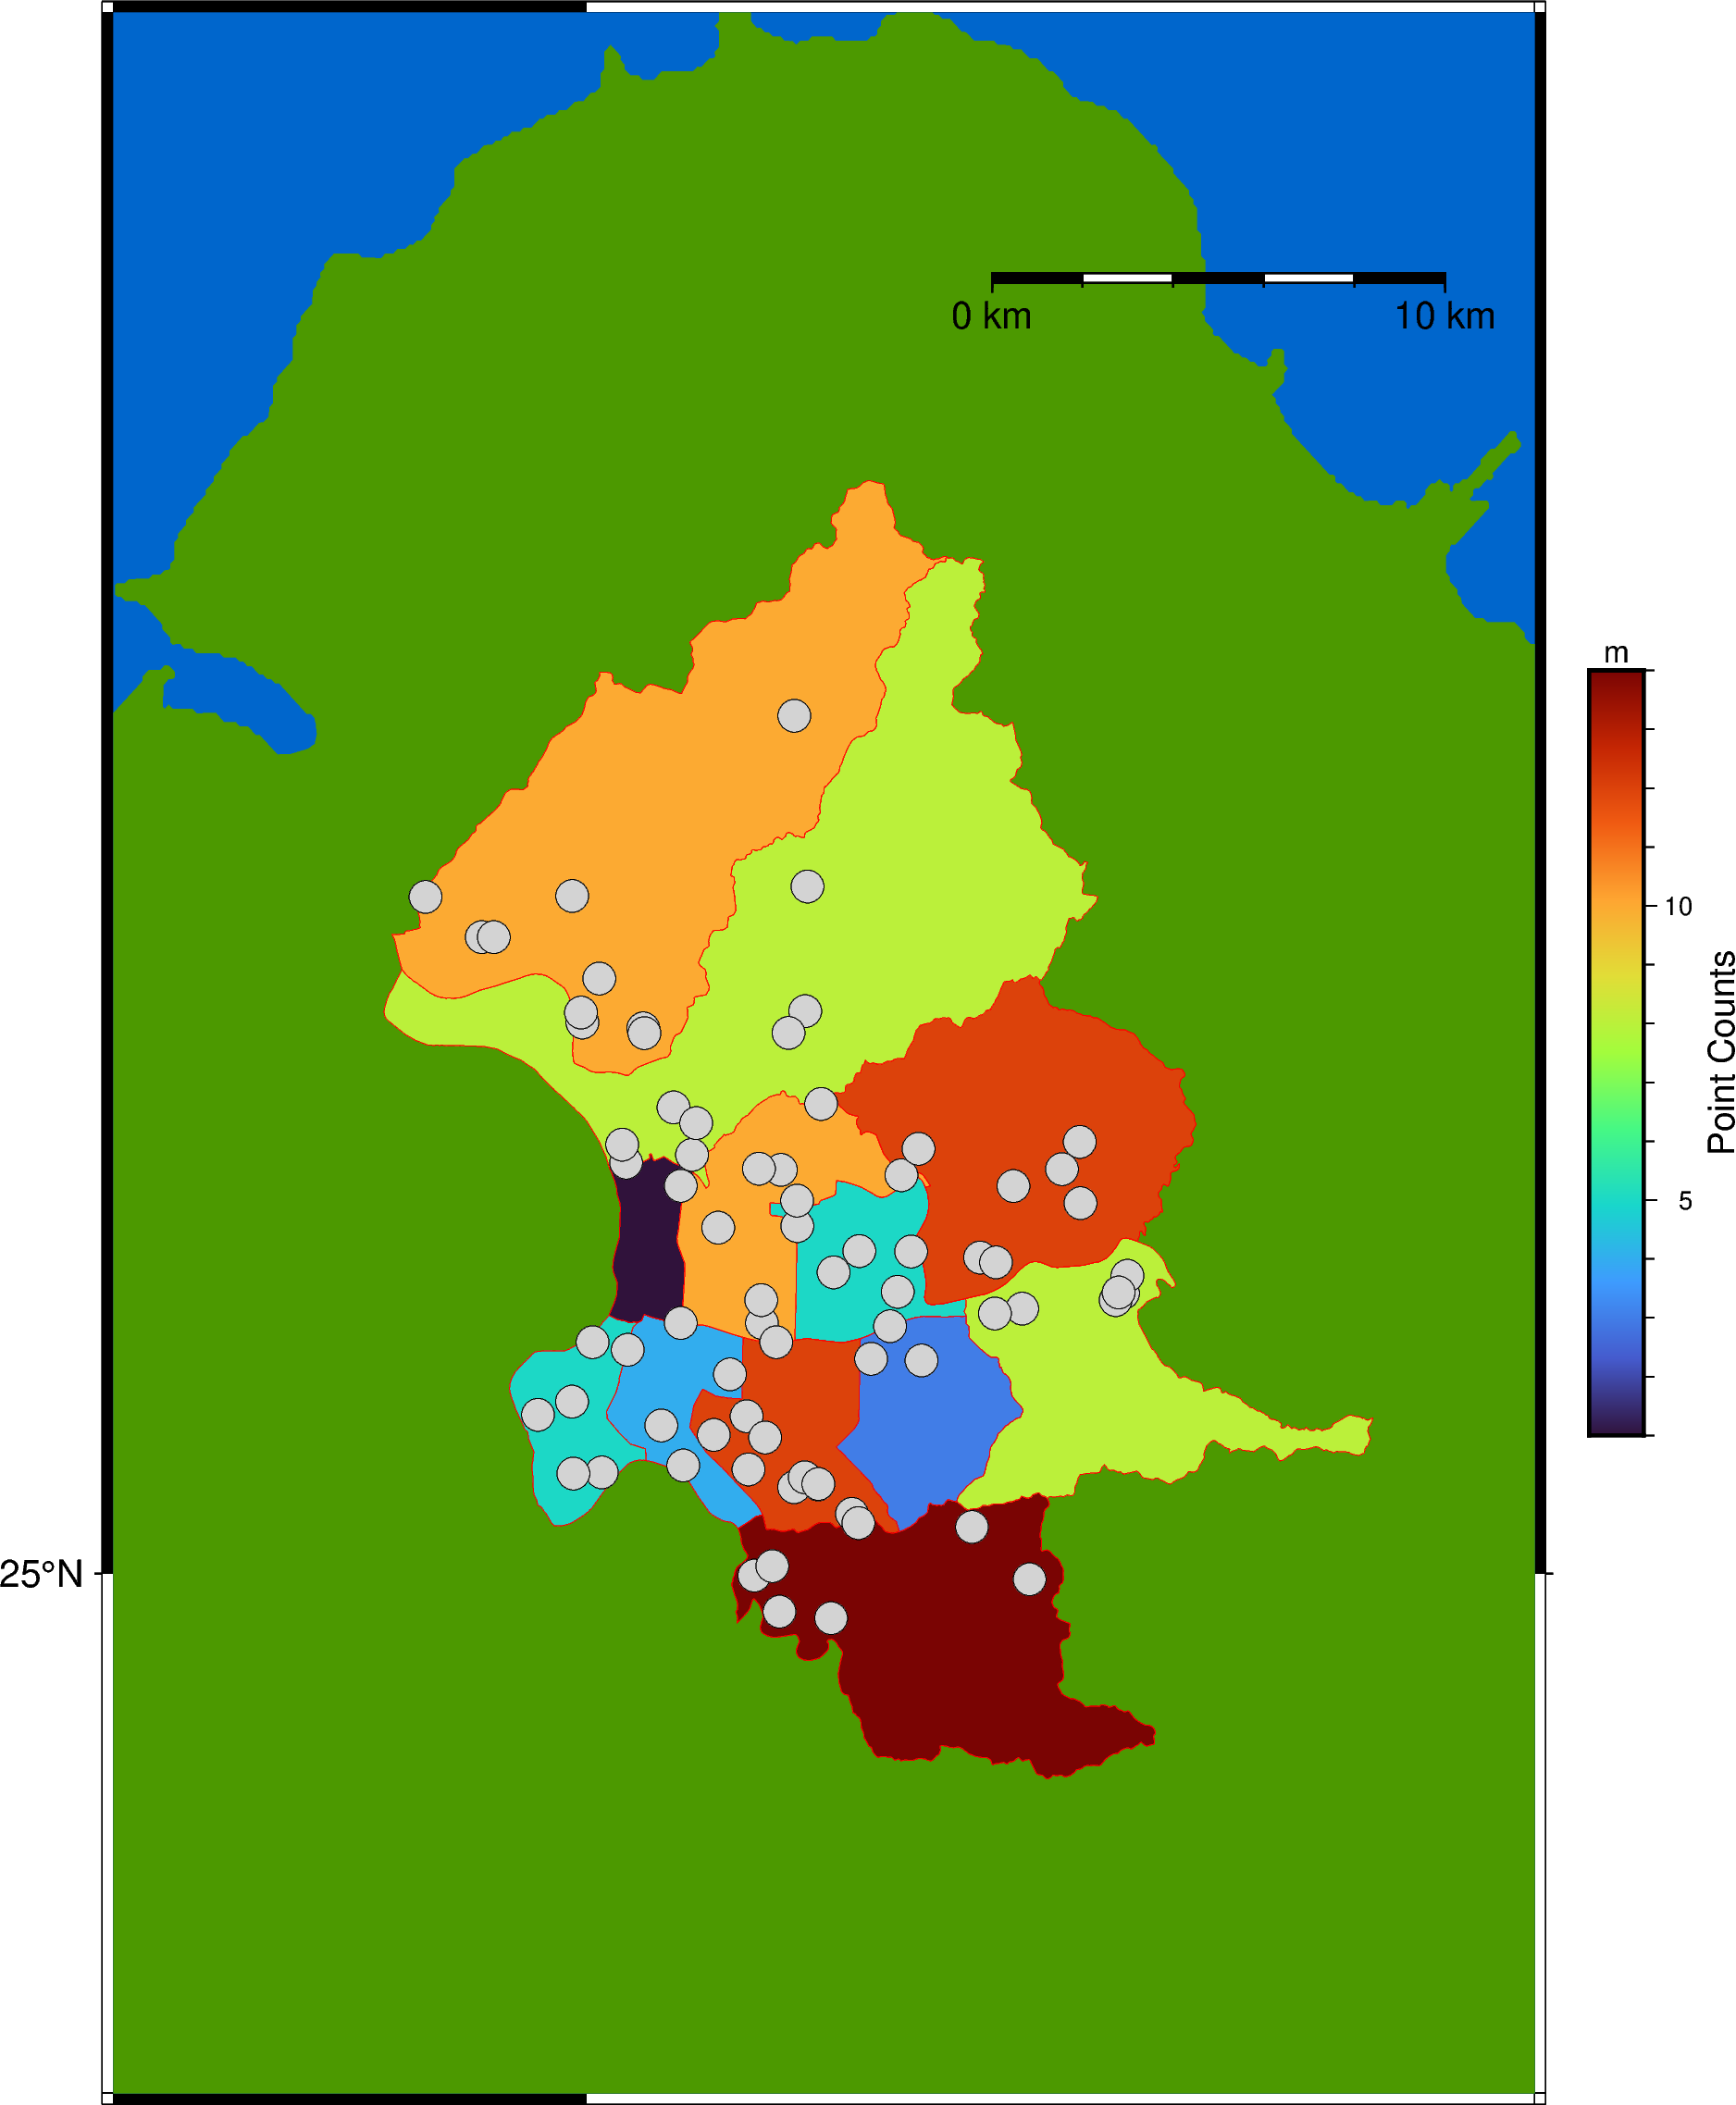

In [7]:
fig = pygmt.Figure()
fig.basemap(region = [121.4,121.7,24.9,25.3],
            projection = 'M13c',
            frame="a1f0.5g1",
            verbose=True)
fig.coast(resolution = "f",
          # borders=["1/0.5p,black", "2/0.5p,red", "3/0.5p,blue"],
          # shorelines= "0.5, black",
          water = "0/102/204",
          land="76/153/0",
          map_scale = "f121:38/25:15/20/10+u")

#by gemini
#create colormap
min_val = taipei['point_count'].copy().min()
max_val = taipei['point_count'].copy().max()

pygmt.makecpt(cmap="turbo", 
              series=f"{min_val}/{max_val}/{(max_val-min_val)/10}", 
              continuous=True)

fig.plot(
    data = taipei[['geometry','CBC', 'point_count']],# 這裡放你的 GeoDataFrame    # 【關鍵】指定要用哪一欄數值來決定顏色
    aspatial = "Z=point_count",
    cmap = True,                    # 【關鍵】告訴 PyGMT 使用剛剛 makecpt 做好的色標
    pen = '0.1p,red',
    fill = '+z'                   # 【關鍵】"+z" 代表「依據 Z 值 (zvalue) 填色」
)

fig.plot(x=df[df['CityName'] == '臺北市']['Longitude'], y = df[df['CityName'] == '臺北市']['Latitude'],
         style = 'c0.3c',
         pen = '0.1p,black',
         fill='lightgray',
        # transparency = 80
        )

fig.colorbar(
    frame=["x+lPoint Counts", "y+lm"], # x軸標籤, y軸單位
    position="JMR+o0.5c/0c+w7c/0.5c"   # 位置設定 (右側中間, 偏移, 長寬)
)

fig.savefig("Taipei_speedlimit_station.png", dpi = 300 ,crop = "+m2c")
fig.show()

In [8]:
county_outlines = gdf.dissolve(gdf.COUNTYNAME)['geometry']
taipei_outlines = gpd.GeoDataFrame(
        geometry=[county_outlines['臺北市']], 
        crs=gdf.crs
    )
county_outlines

COUNTYNAME
南投縣    POLYGON ((120.81371 23.60095, 120.81312 23.600...
嘉義市    POLYGON ((120.44964 23.44342, 120.44946 23.443...
嘉義縣    MULTIPOLYGON (((120.28462 23.36349, 120.28457 ...
基隆市    MULTIPOLYGON (((121.75001 25.10941, 121.75004 ...
宜蘭縣    MULTIPOLYGON (((121.84564 24.64349, 121.8457 2...
屏東縣    MULTIPOLYGON (((120.38236 22.35371, 120.38244 ...
彰化縣    POLYGON ((120.45492 23.81673, 120.45492 23.816...
新北市    POLYGON ((121.45038 24.79093, 121.45037 24.790...
新竹市    POLYGON ((120.96073 24.75085, 120.96062 24.750...
新竹縣    POLYGON ((121.02634 24.75777, 121.02637 24.757...
桃園市    POLYGON ((121.24302 24.80857, 121.2429 24.8084...
澎湖縣    MULTIPOLYGON (((119.44189 23.22129, 119.44195 ...
臺中市    POLYGON ((120.65566 24.03067, 120.65191 24.028...
臺北市    POLYGON ((121.53184 25.00869, 121.53173 25.008...
臺南市    POLYGON ((120.26957 22.89681, 120.26937 22.896...
臺東縣    MULTIPOLYGON (((120.9464 22.45688, 120.94604 2...
花蓮縣    POLYGON ((121.37713 23.28345, 121.37713 23.283...
苗栗縣    POLYGON ((120

basemap [INFORMATION]: Constructing the basemap
basemap [INFORMATION]: Central meridian not given, default to 121.55
basemap [INFORMATION]: Map scale is 2.56891 km per cm or 1:256891.
basemap [INFORMATION]: Save current gridline information to gmt.history
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

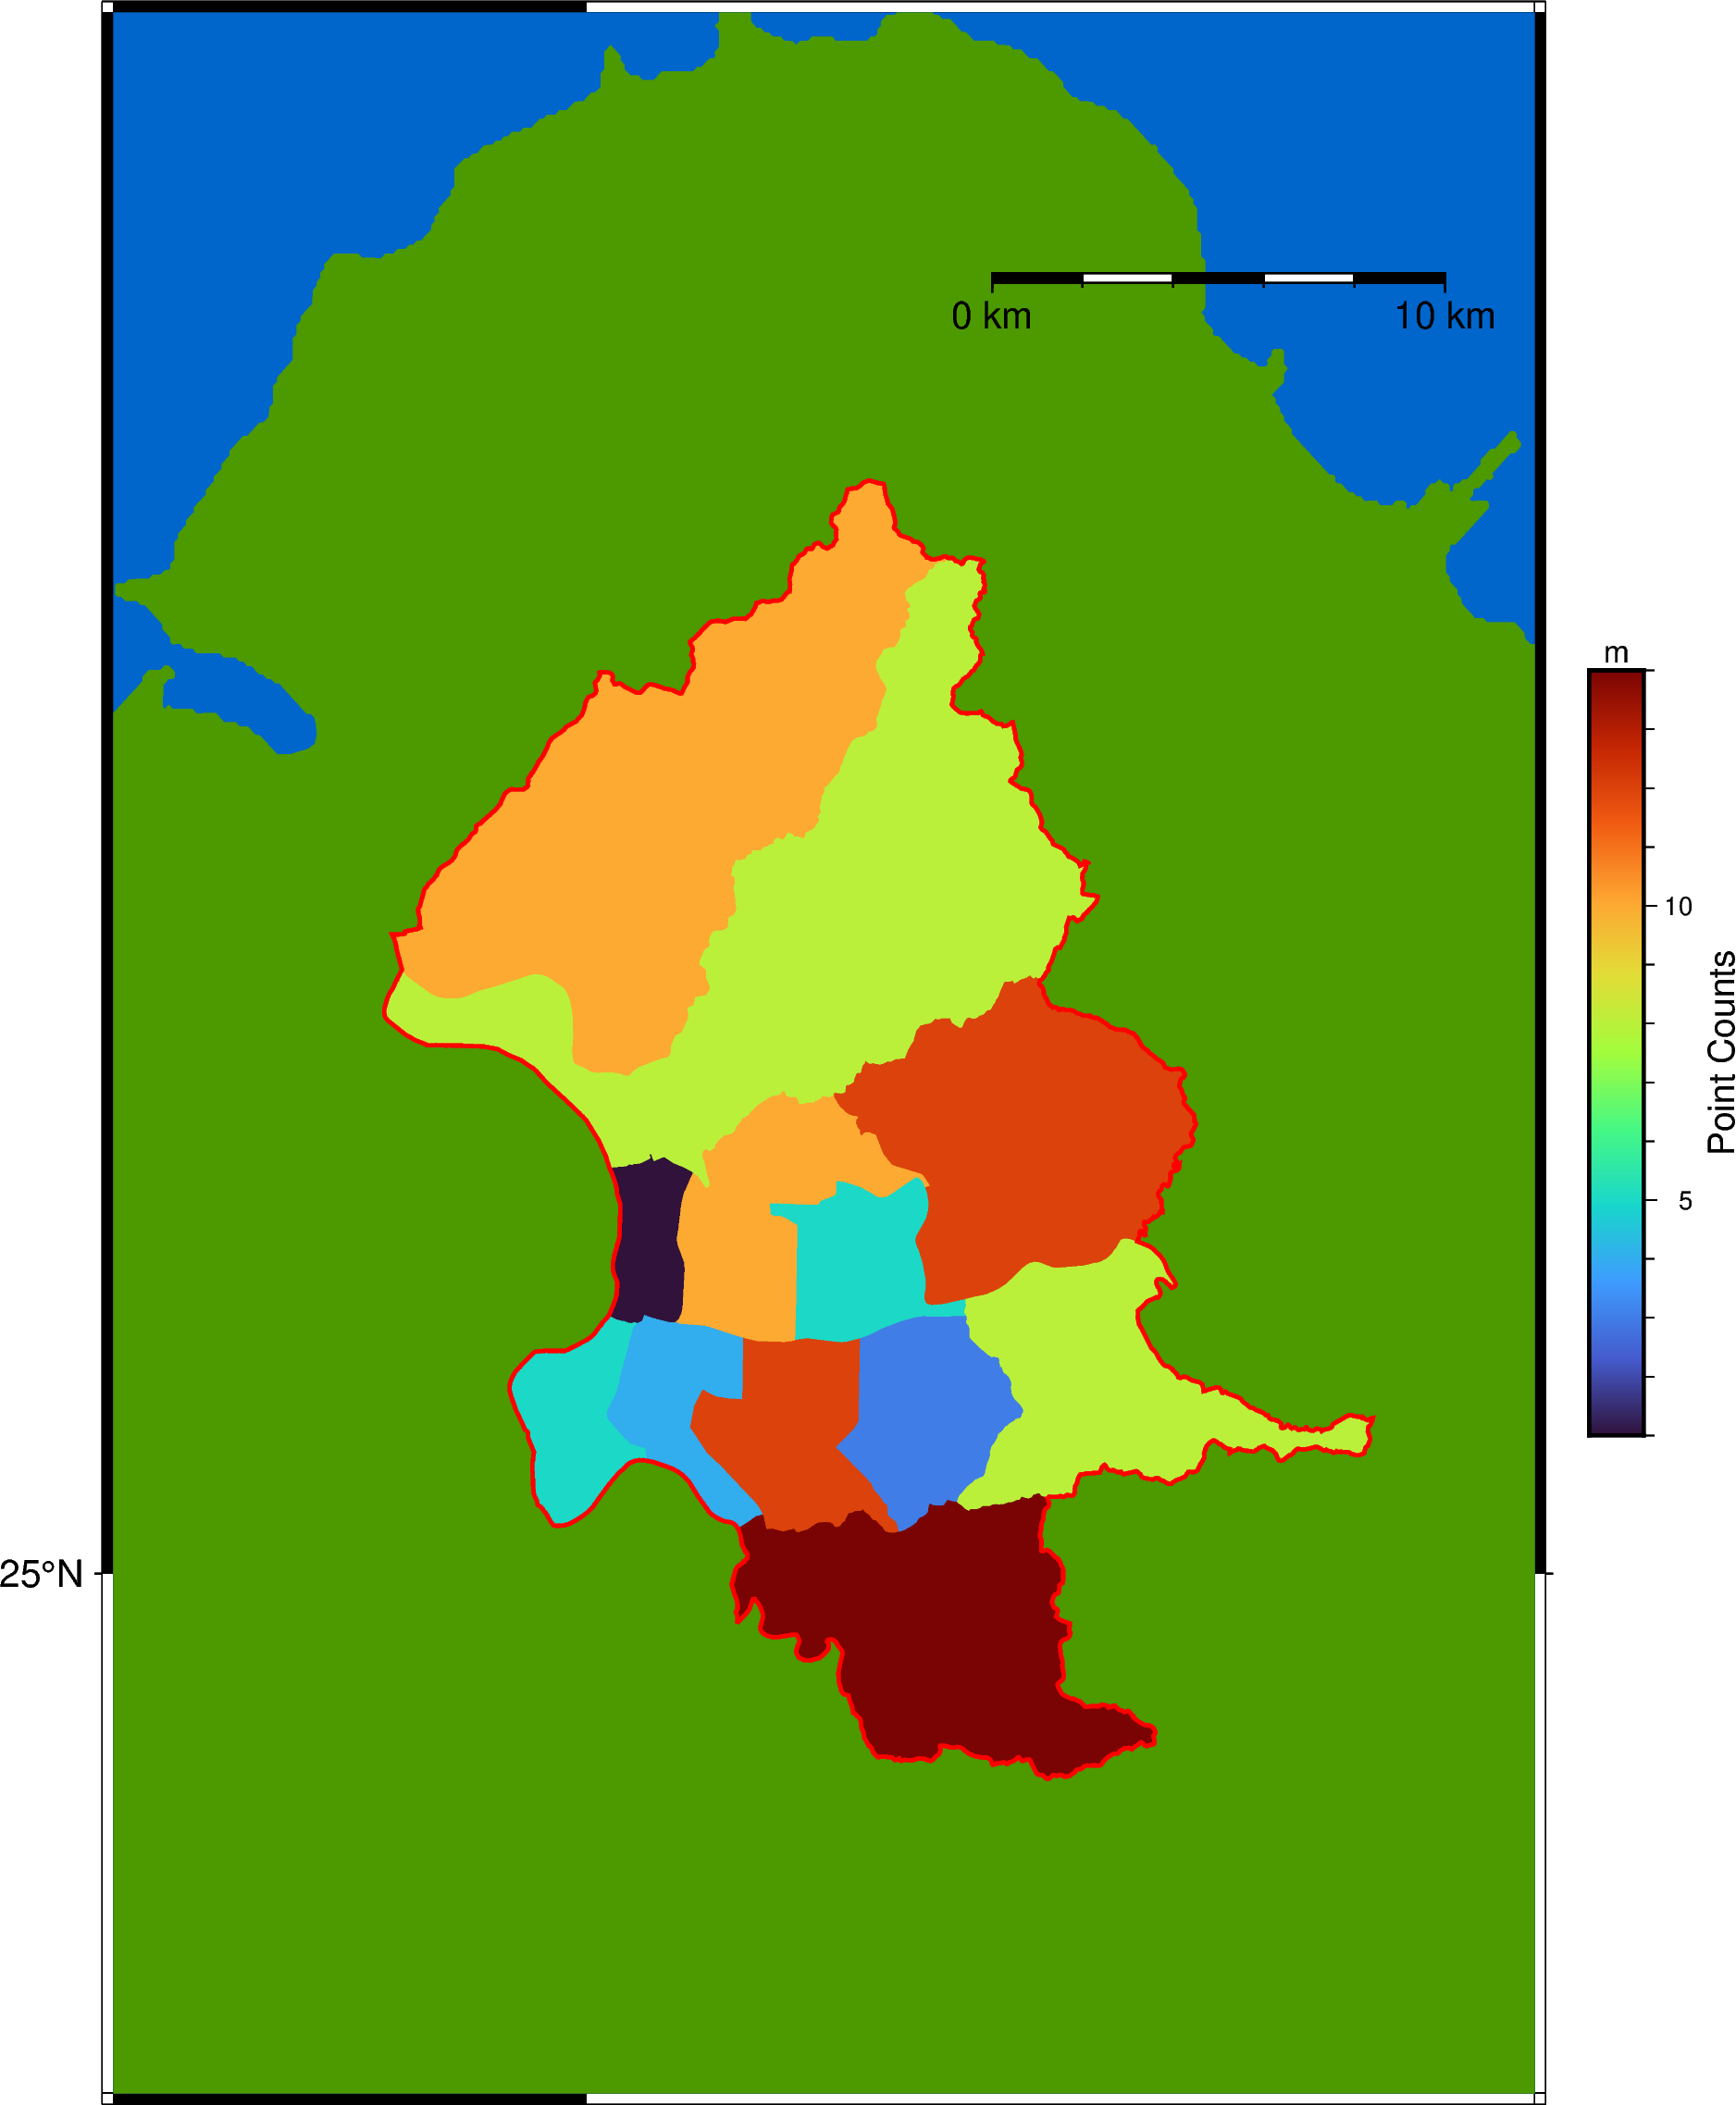

In [9]:
fig = pygmt.Figure()
fig.basemap(region = [121.4,121.7,24.9,25.3],
            projection = 'M13c',
            frame="a1f0.5g1",
            verbose=True)
fig.coast(resolution = "f",
          # borders=["1/0.5p,black", "2/0.5p,red", "3/0.5p,blue"],
          # shorelines= "0.5, black",
          water = "0/102/204",
          land="76/153/0",
          map_scale = "f121:38/25:15/20/10+u")

#by gemini
#create colormap
min_val = taipei['point_count'].min()
max_val = taipei['point_count'].max()

pygmt.makecpt(cmap="turbo", 
              series=f"{min_val}/{max_val}/{(max_val-min_val)/10}", 
              continuous=True)

fig.plot(
    data = taipei[['geometry','CBC', 'point_count']],# 這裡放你的 GeoDataFrame    # 【關鍵】指定要用哪一欄數值來決定顏色
    aspatial = "Z=point_count",
    cmap = True,                    # 【關鍵】告訴 PyGMT 使用剛剛 makecpt 做好的色標
    # pen = '0.1p,red',
    fill = '+z'                   # 【關鍵】"+z" 代表「依據 Z 值 (zvalue) 填色」
)
fig.plot(
    data = taipei_outlines,
    pen = '1p,red',
)
# fig.plot(x=df['Longitude'], y = df['Latitude'],
#          style = 'c0.05c',
#          pen = '0.1p,black',
#          fill='lightgray',
#         transparency = 80)

fig.colorbar(
    frame=["x+lPoint Counts", "y+lm"], # x軸標籤, y軸單位
    position="JMR+o0.5c/0c+w7c/0.5c"   # 位置設定 (右側中間, 偏移, 長寬)
)
fig.savefig('Taipei_speedlimit_bydistrict.png', dpi=300 ,crop = "+m2c")
fig.show()

## 縣市總面積

In [10]:
area = pd.read_csv('area.csv', sep = ',')
# town_area = area.set_index('TOWNNAME', drop = True)
total_area = area.groupby(area.COUNTYNAME)['AREA'].sum()
total_area.reindex(county_outlines.index)
# town_area

COUNTYNAME
南投縣    4106.42
嘉義市      60.03
嘉義縣    1903.66
基隆市     132.76
宜蘭縣    2143.62
屏東縣    2775.60
彰化縣    1074.38
新北市    2052.57
新竹市     104.16
新竹縣    1427.54
桃園市    1220.94
澎湖縣     126.86
臺中市    2214.89
臺北市     271.80
臺南市    2191.67
臺東縣    3515.27
花蓮縣    4628.57
苗栗縣    1820.32
連江縣      28.80
金門縣     151.65
雲林縣    1290.85
高雄市    2951.84
Name: AREA, dtype: float64

In [11]:
taipei['TOTAL_AREA'] = taipei['COUNTYNAME'].map(total_area)
if 'TOWN_AREA'  in taipei.columns:
    taipei = taipei.drop(columns=['TOWN_AREA'])
    taipei = taipei.merge(area[['TOWNNAME','AREA']], on=['TOWNNAME'], how = 'left')
else:
    taipei = taipei.merge(area[['TOWNNAME','AREA']], on=['TOWNNAME'], how = 'left')
taipei = taipei.rename(columns={'AREA':'TOWN_AREA'})
taipei['AVG_CBC'] = taipei['CBC']/taipei['TOTAL_AREA']
taipei['AVG_point'] = taipei['point_count']/taipei['TOWN_AREA']
taipei

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry,point_count,CBC,TOTAL_AREA,TOWN_AREA,AVG_CBC,AVG_point
0,A01,63000010,臺北市,松山區,Songshan District,A,63000,"POLYGON ((121.572 25.07263, 121.57206 25.07224...",5,92,271.8,9.29,0.338484,0.538213
1,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044...",12,92,271.8,11.36,0.338484,1.056338
2,A02,63000030,臺北市,大安區,Da'an District,A,63000,"POLYGON ((121.54103 25.04464, 121.54162 25.044...",12,92,271.8,27.40,0.338484,0.437956
3,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048...",4,92,271.8,7.61,0.338484,0.525624
4,A03,63000050,臺北市,中正區,Zhongzheng District,A,63000,"POLYGON ((121.51738 25.04843, 121.51762 25.048...",4,92,271.8,10.21,0.338484,0.391773
5,A05,63000070,臺北市,萬華區,Wanhua District,A,63000,"POLYGON ((121.50899 25.04829, 121.50945 25.048...",5,92,271.8,8.85,0.338484,0.564972
6,A09,63000060,臺北市,大同區,Datong District,A,63000,"POLYGON ((121.51354 25.08079, 121.51411 25.079...",1,92,271.8,5.68,0.338484,0.176056
7,A10,63000040,臺北市,中山區,Zhongshan District,A,63000,"POLYGON ((121.54232 25.09184, 121.5425 25.0917...",10,92,271.8,13.68,0.338484,0.730994
8,A10,63000040,臺北市,中山區,Zhongshan District,A,63000,"POLYGON ((121.54232 25.09184, 121.5425 25.0917...",10,92,271.8,10.52,0.338484,0.950570
9,A11,63000080,臺北市,文山區,Wenshan District,A,63000,"POLYGON ((121.59711 25.0146, 121.59721 25.0144...",14,92,271.8,31.51,0.338484,0.444303


basemap [INFORMATION]: Constructing the basemap
basemap [INFORMATION]: Central meridian not given, default to 121.55
basemap [INFORMATION]: Map scale is 2.56891 km per cm or 1:256891.
basemap [INFORMATION]: Save current gridline information to gmt.history
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\nianz\anaconda3\envs\pygmt2025\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

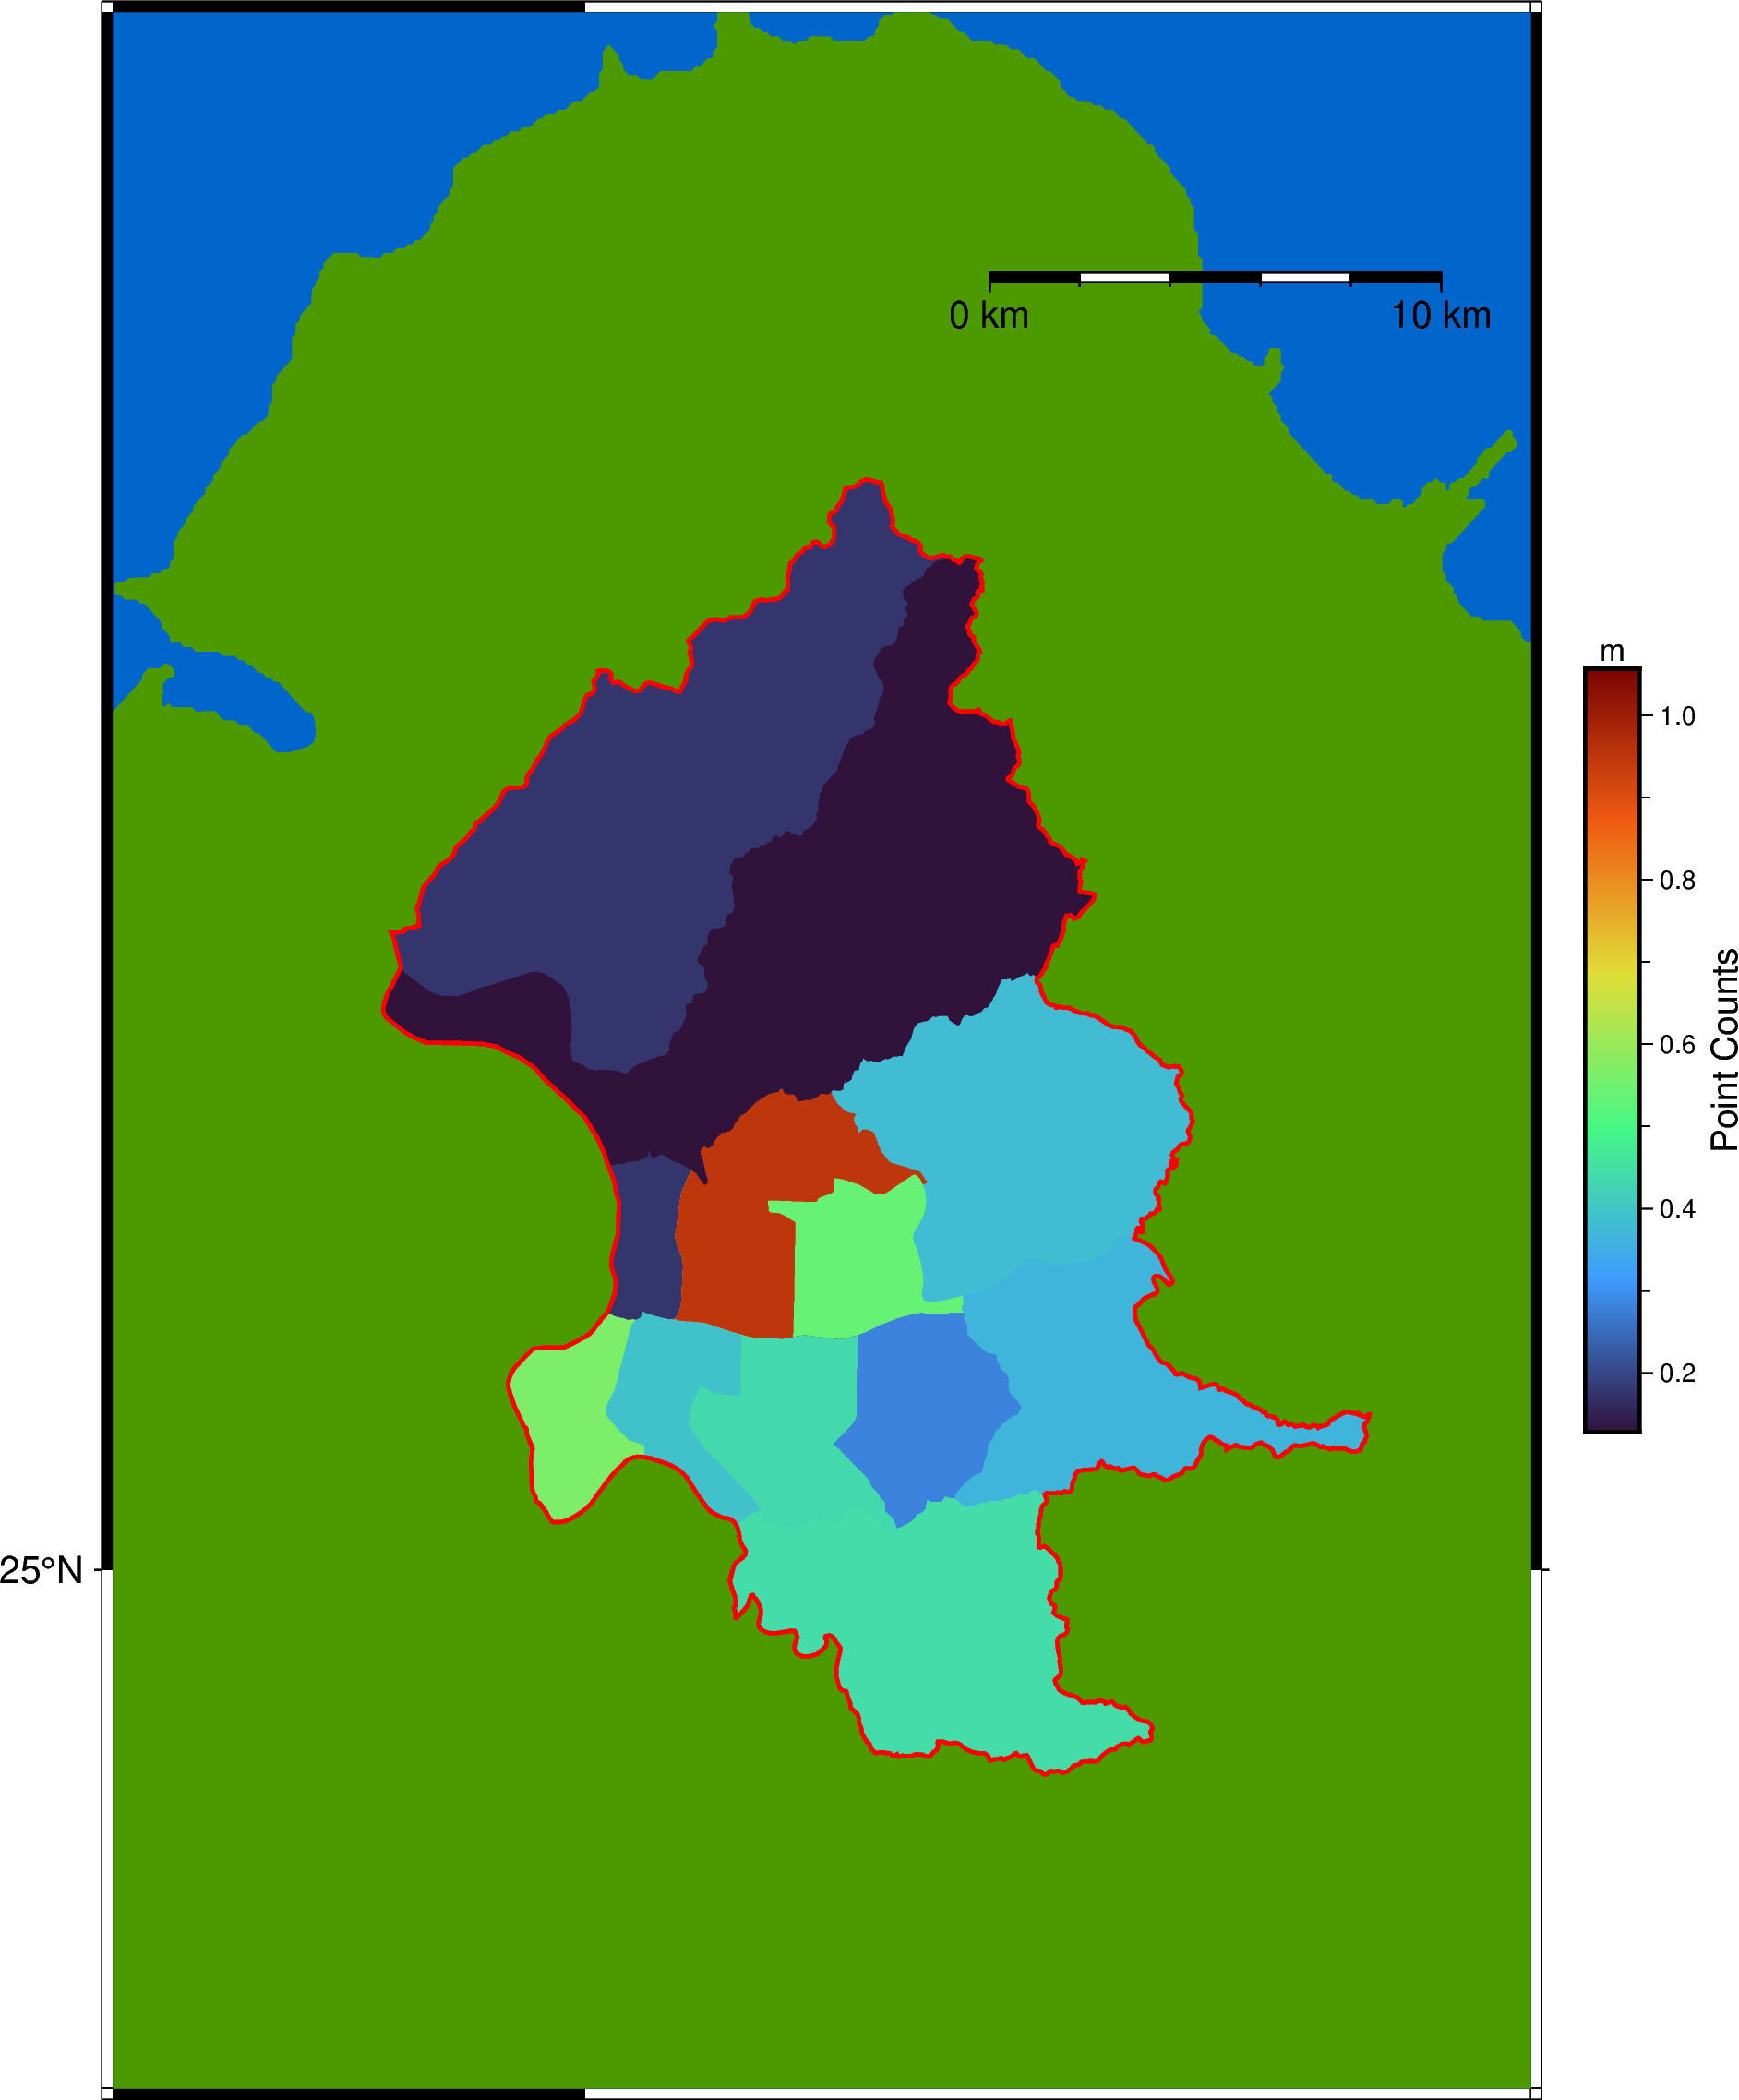

In [12]:
fig = pygmt.Figure()
fig.basemap(region = [121.4,121.7,24.9,25.3],
            projection = 'M13c',
            frame="a1f0.5g1",
            verbose=True)
fig.coast(resolution = "f",
          # borders=["1/0.5p,black", "2/0.5p,red", "3/0.5p,blue"],
          # shorelines= "0.5, black",
          water = "0/102/204",
          land="76/153/0",
          map_scale = "f121:38/25:15/20/10+u")

#by gemini
#create colormap
min_val = taipei[taipei['AVG_point']>0]['AVG_point'].min()
max_val = taipei['AVG_point'].max()

pygmt.makecpt(cmap="turbo", 
              series=f"{min_val}/{max_val}/{(max_val-min_val)/5}", 
              continuous=True,
              # log = True
             )

fig.plot(
    data = taipei[['geometry','CBC', 'point_count', 'AVG_point', 'AVG_CBC']],# 這裡放你的 GeoDataFrame    # 【關鍵】指定要用哪一欄數值來決定顏色
    aspatial = "Z=AVG_point",
    cmap = True,                    # 【關鍵】告訴 PyGMT 使用剛剛 makecpt 做好的色標
    # pen = '0.1p,red',
    fill = '+z'                   # 【關鍵】"+z" 代表「依據 Z 值 (zvalue) 填色」
)
fig.plot(
    data= taipei_outlines,
    pen = '1p,red',
)
# fig.plot(x=df['Longitude'], y = df['Latitude'],
#          style = 'c0.05c',
#          pen = '0.1p,black',
#          fill='lightgray',
#         transparency = 80)

fig.colorbar(
    frame=["x+lPoint Counts", "y+lm"], # x軸標籤, y軸單位
    position="JMR+o0.5c/0c+w7c/0.5c"   # 位置設定 (右側中間, 偏移, 長寬)
)
fig.savefig('Taipei_speedlimit_by_area_average.png', dpi = 300 ,crop = "+m2c")
fig.show()

## 篩選非高速公路測速照相

In [13]:
# 1. 確保您的資料是 GeoDataFrame 且有設座標系 (假設原始是經緯度 EPSG:4326)
# gdf = ... (您的原始資料)

# 2. 【關鍵】轉成投影座標 (單位變公尺)
# 台灣建議用 EPSG:3826 (TWD97 121分帶) 或 EPSG:3825 (119分帶)
# 如果是全球資料，可用 EPSG:3857 (Web Mercator) 但長度會有變形，或依區域選 UTM
df_ = gpd.GeoDataFrame(df[df['limit'] < 99], geometry=gpd.points_from_xy(df[df['limit'] < 99]['Longitude'], df[df['limit'] < 99]['Latitude']), crs="EPSG:4326") 
df_ = df_.to_crs(epsg=3826) 
df_

,CityName,RegionName,Address,DeptNm,BranchNm,Longitude,Latitude,direct,limit,geometry
0,連江縣,南竿鄉,介壽村47-10號前,連江縣警察局,南竿警察所,119.95137,26.160198,順向(往介壽村方向),30,POINT (145163.246 2894716.324)
1,連江縣,北竿鄉,塘岐村168號前,連江縣警察局,北竿警察所,119.99763,26.223022,順向(往機場方向),30,POINT (149842.136 2901640.111)
2,連江縣,北竿鄉,板里村46號前,連江縣警察局,北竿警察所,119.97415,26.216692,順向(往白沙方向),30,POINT (147490.289 2900957.155)
3,金門縣,金城鎮,西海路水頭路段,金門縣警察局,金城分局,118.29999,24.411718,東西雙向,50,POINT (-23889.518 2703289.403)
4,金門縣,金城鎮,環島南路小西門路段,金門縣警察局,金城分局,118.32414,24.413134,東西雙向,60,POINT (-21435.52 2703398.786)
...,...,...,...,...,...,...,...,...,...,...
2518,國道3甲,NaN,國道三甲西向1.7公里,國道公路警察局,國道公路警九隊,121.56336,25.010769,往西,80,POINT (306861.191 2767088.549)
2519,國道3甲,NaN,國道三甲西向3.4公里,國道公路警察局,國道公路警九隊,121.57856,25.005106,往西,80,POINT (308398.072 2766467.747)
2520,國道3甲,NaN,國道三號甲線西向1.7公里,國道公路警察局,國道公路警九隊,121.56336,25.010769,往西,80,POINT (306861.191 2767088.549)
2521,國道3甲,NaN,國道三號甲線西向3.4公里,國道公路警察局,國道公路警九隊,121.57856,25.005106,往西,80,POINT (308398.072 2766467.747)


## 計算測速照相密度

In [14]:
# 3. 設定搜尋半徑 (例如：半徑 5公里 = 5000公尺)
radius = 5000
# for i in radius:
# 4. 建立緩衝區 (畫圓)
# 這會產生一堆圓形的幾何形狀
buffers = df_.copy()
buffers['geometry'] = buffers.buffer(radius)

# 5. 空間連結 (Spatial Join)
# 邏輯：找出「原本的點」落在「哪些圓」裡面
joined = gpd.sjoin(df_, buffers, how="inner", predicate="within")

# 6. 計算數量
# index_right 代表是「哪一個圓(測站)」
# 我們計算每個圓裡面有多少個點
counts = joined.groupby('index_right').size()

# 7. 扣掉自己 (題目是問"其他"測站，通常不包含自己)
df['Station_Count'] = counts

# 8. (選用) 填補 NaN (有些測站附近完全沒人，會變 NaN，補 0)
df['Station_Count'] = df['Station_Count'].fillna(0)
taipei_count = df[df['CityName'] == '臺北市'].copy()
# taipei_count.to_csv(f'taipei_count_{i}m.csv')

basemap [INFORMATION]: Constructing the basemap
basemap [INFORMATION]: Central meridian not given, default to 121.55
basemap [INFORMATION]: Map scale is 2.56891 km per cm or 1:256891.
basemap [INFORMATION]: Save current gridline information to gmt.history


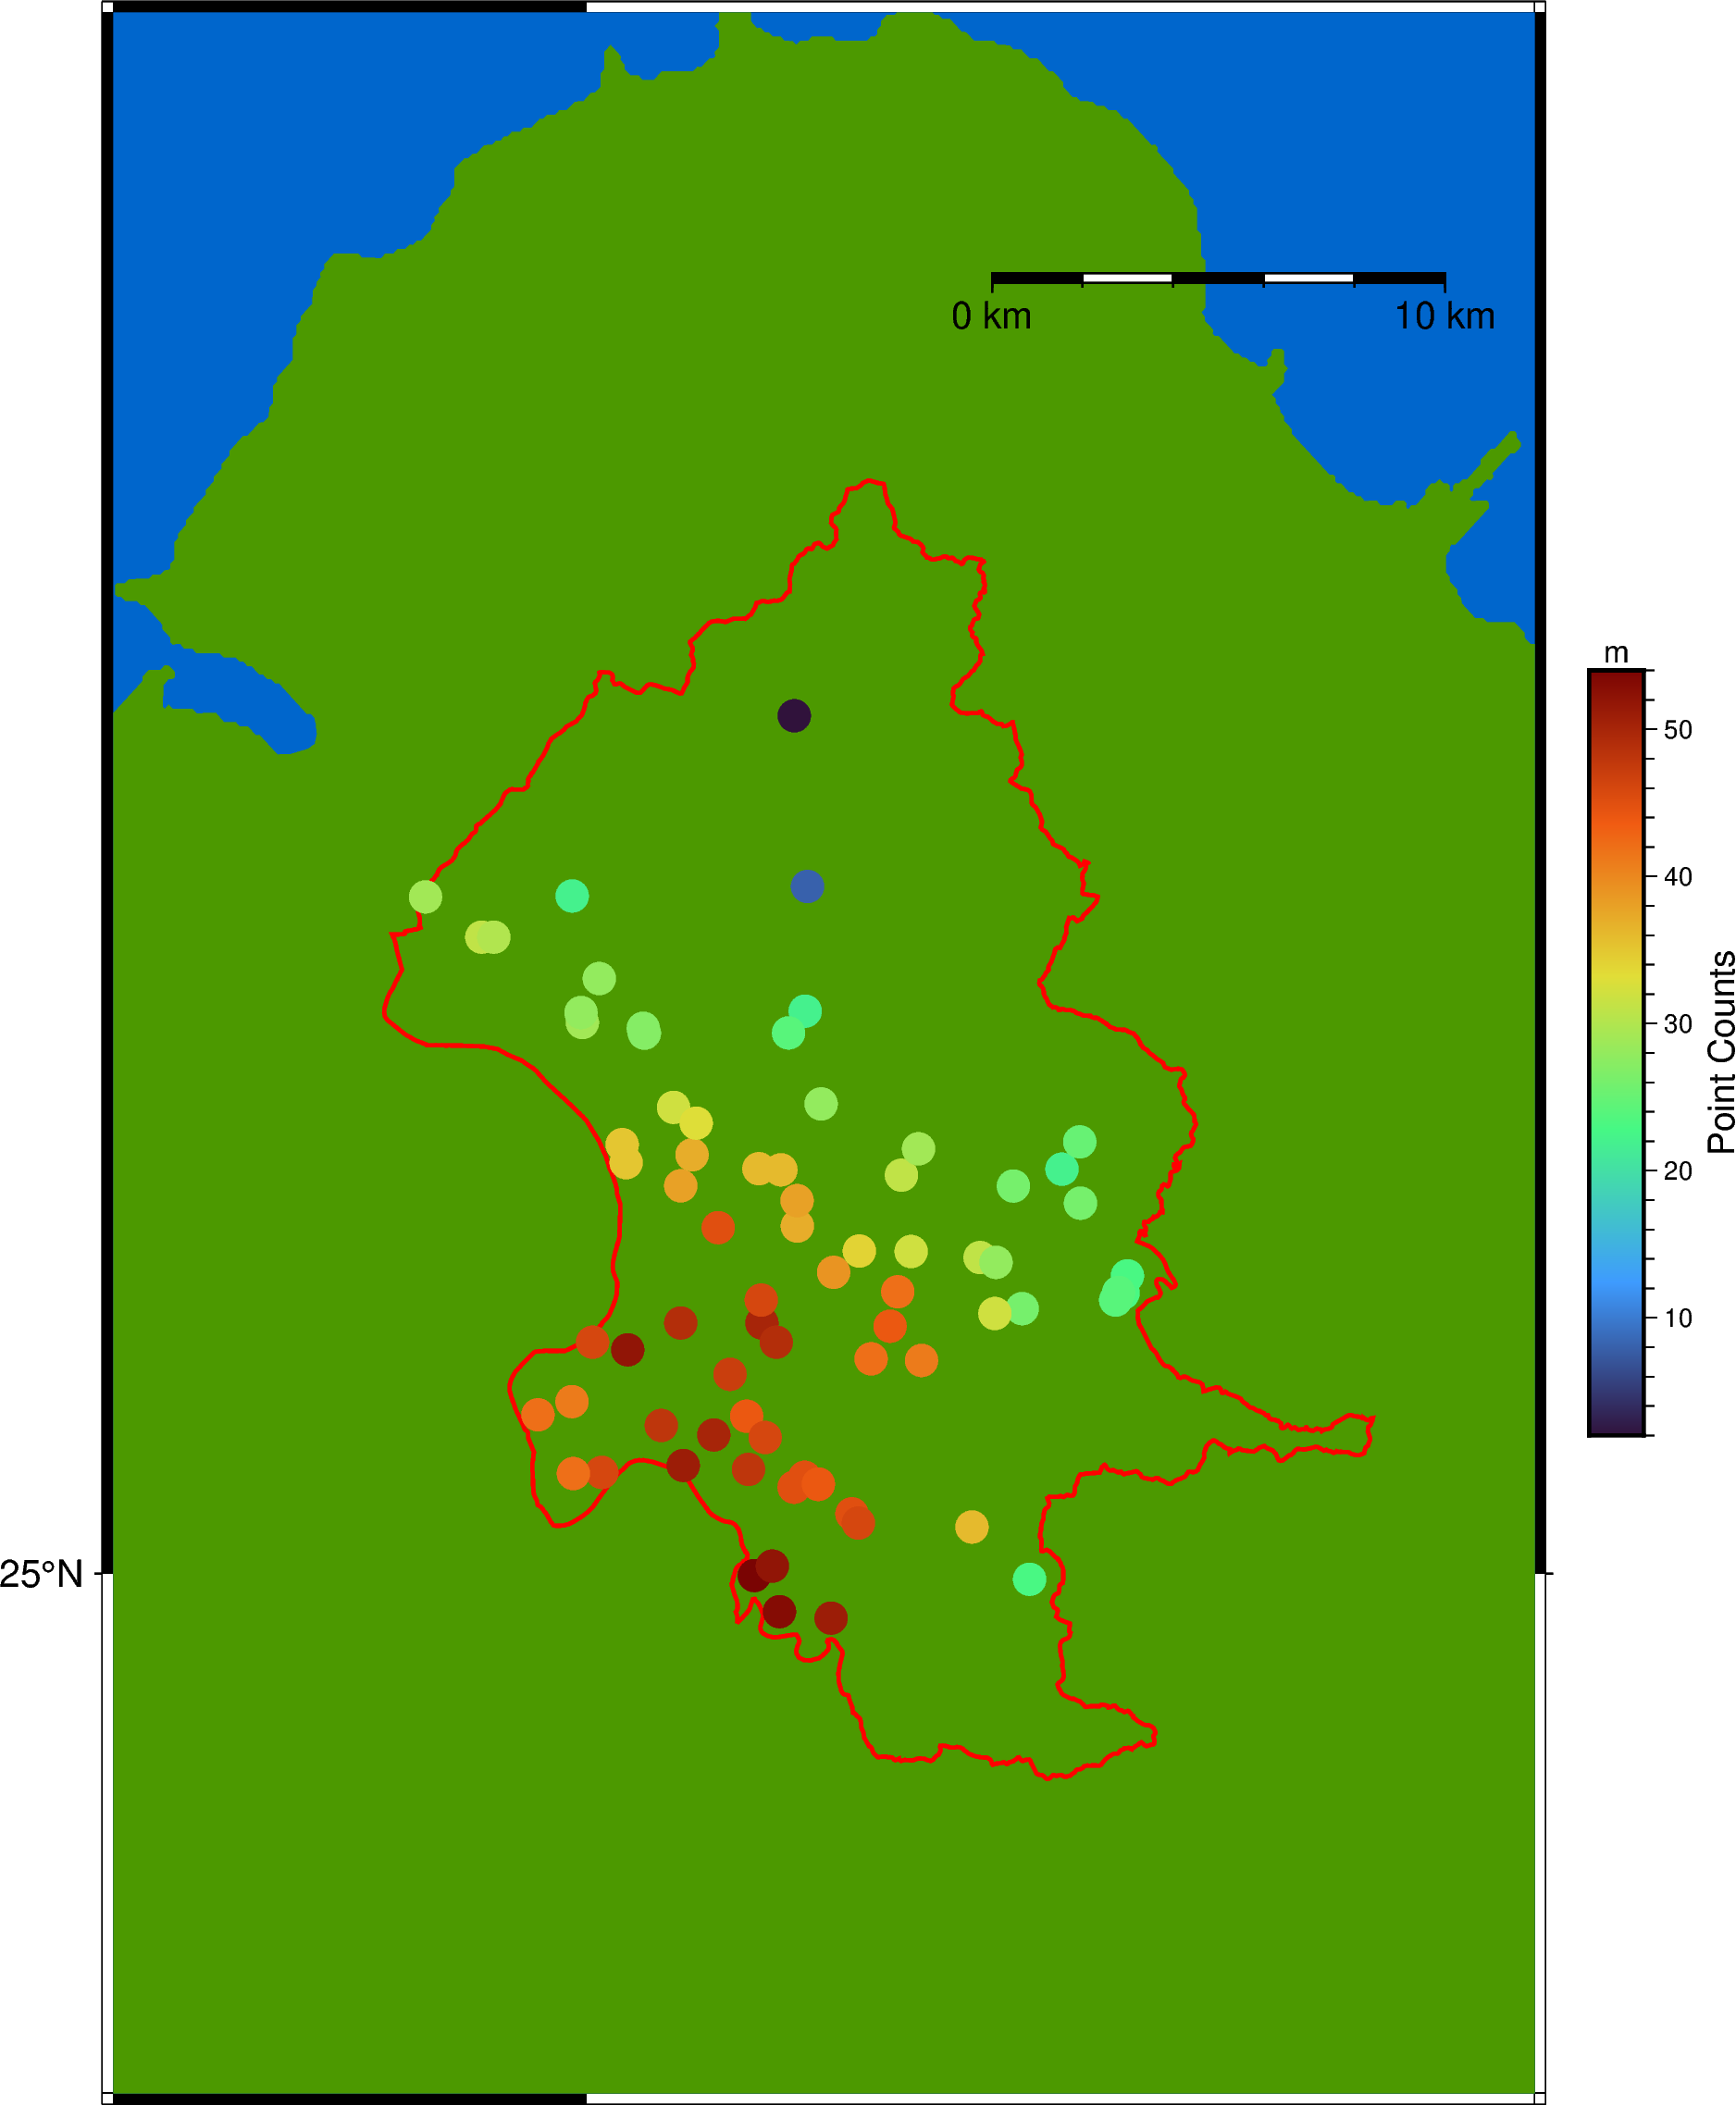

In [15]:
fig = pygmt.Figure()
fig.basemap(region = [121.4,121.7,24.9,25.3],
            projection = 'M13c',
            frame="a1f0.5g1",
            verbose=True)
fig.coast(resolution = "f",
          # borders=["1/0.5p,black", "2/0.5p,red", "3/0.5p,blue"],
          # shorelines= "0.5, black",
          water = "0/102/204",
          land="76/153/0",
          map_scale = "f121:38/25:15/20/10+u")

#by gemini
#create colormap
min_val = taipei_count['Station_Count'].min()
max_val = taipei_count['Station_Count'].max()

pygmt.makecpt(cmap="turbo", 
              series=f"{min_val}/{max_val+round(np.log(max_val))}/{(max_val-min_val)/5}", 
              continuous=True,
              # log = True
             )

# fig.plot(
#     data = gdf[['geometry','CBC', 'point_count', 'AVG_point', 'AVG_CBC']],# 這裡放你的 GeoDataFrame    # 【關鍵】指定要用哪一欄數值來決定顏色
#     aspatial = "Z=AVG_CBC",
#     cmap = True,                    # 【關鍵】告訴 PyGMT 使用剛剛 makecpt 做好的色標
#     # pen = '0.1p,red',
#     fill = '+z'                   # 【關鍵】"+z" 代表「依據 Z 值 (zvalue) 填色」
# )
fig.plot(
    data = taipei_outlines,
    pen = '1p,red',
)
fig.plot(data = taipei_count[['Longitude', 'Latitude', 'Station_Count']],
        # zvalue = 'Station_Count_5km',
        # x='Longitude', y = 'Latitude',
        aspatial = 'Z=Station_Count',
        style = 'c0.3c',
        cmap =True, 
        # pen = '0.1p,black',
        fill='+z',
        transparency = 0)

fig.colorbar(
    frame=["x+lPoint Counts", "y+lm"], # x軸標籤, y軸單位
    position="JMR+o0.5c/0c+w7c/0.5c"   # 位置設定 (右側中間, 偏移, 長寬)
)
fig.savefig('Taipei_speedlimit_by_radius.png', dpi = 300 ,crop = "+m2c")
fig.show()

## 製作臺北市遮罩

In [16]:
# 1. 定義地圖的四個邊界 (也就是您 fig.coast 設定的 region)
# 例如: region = [119, 123, 21, 26]
min_lon, max_lon, min_lat, max_lat = 121.4, 121.7, 24.9, 25.3

# 2. 建立一個跟地圖一樣大的矩形 (Bounding Box)
# 這代表「整張紙」
bbox = box(min_lon, min_lat, max_lon, max_lat)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326")

taiwan_union = gdf.dissolve()
# 邏輯：遮罩 = 大方框 - 台灣形狀
mask_gdf = bbox_gdf.overlay(taipei_outlines, how='difference')

## 測速照相密度平滑化

In [17]:
bm = pygmt.blockmean(
    data=df[['Longitude', 'Latitude', 'Station_Count']],
    spacing="0.05m",
    region=[121.4, 121.7, 24.9, 25.3],
)
grid = pygmt.surface(
    data=bm,
    region=[121.4, 121.7, 24.9, 25.3], 
    spacing="0.05m",
    tension=0 # 張力參數，控制平滑程度
)

basemap [INFORMATION]: Constructing the basemap
basemap [INFORMATION]: Central meridian not given, default to 121.55
basemap [INFORMATION]: Map scale is 2.56891 km per cm or 1:256891.
basemap [INFORMATION]: Save current gridline information to gmt.history


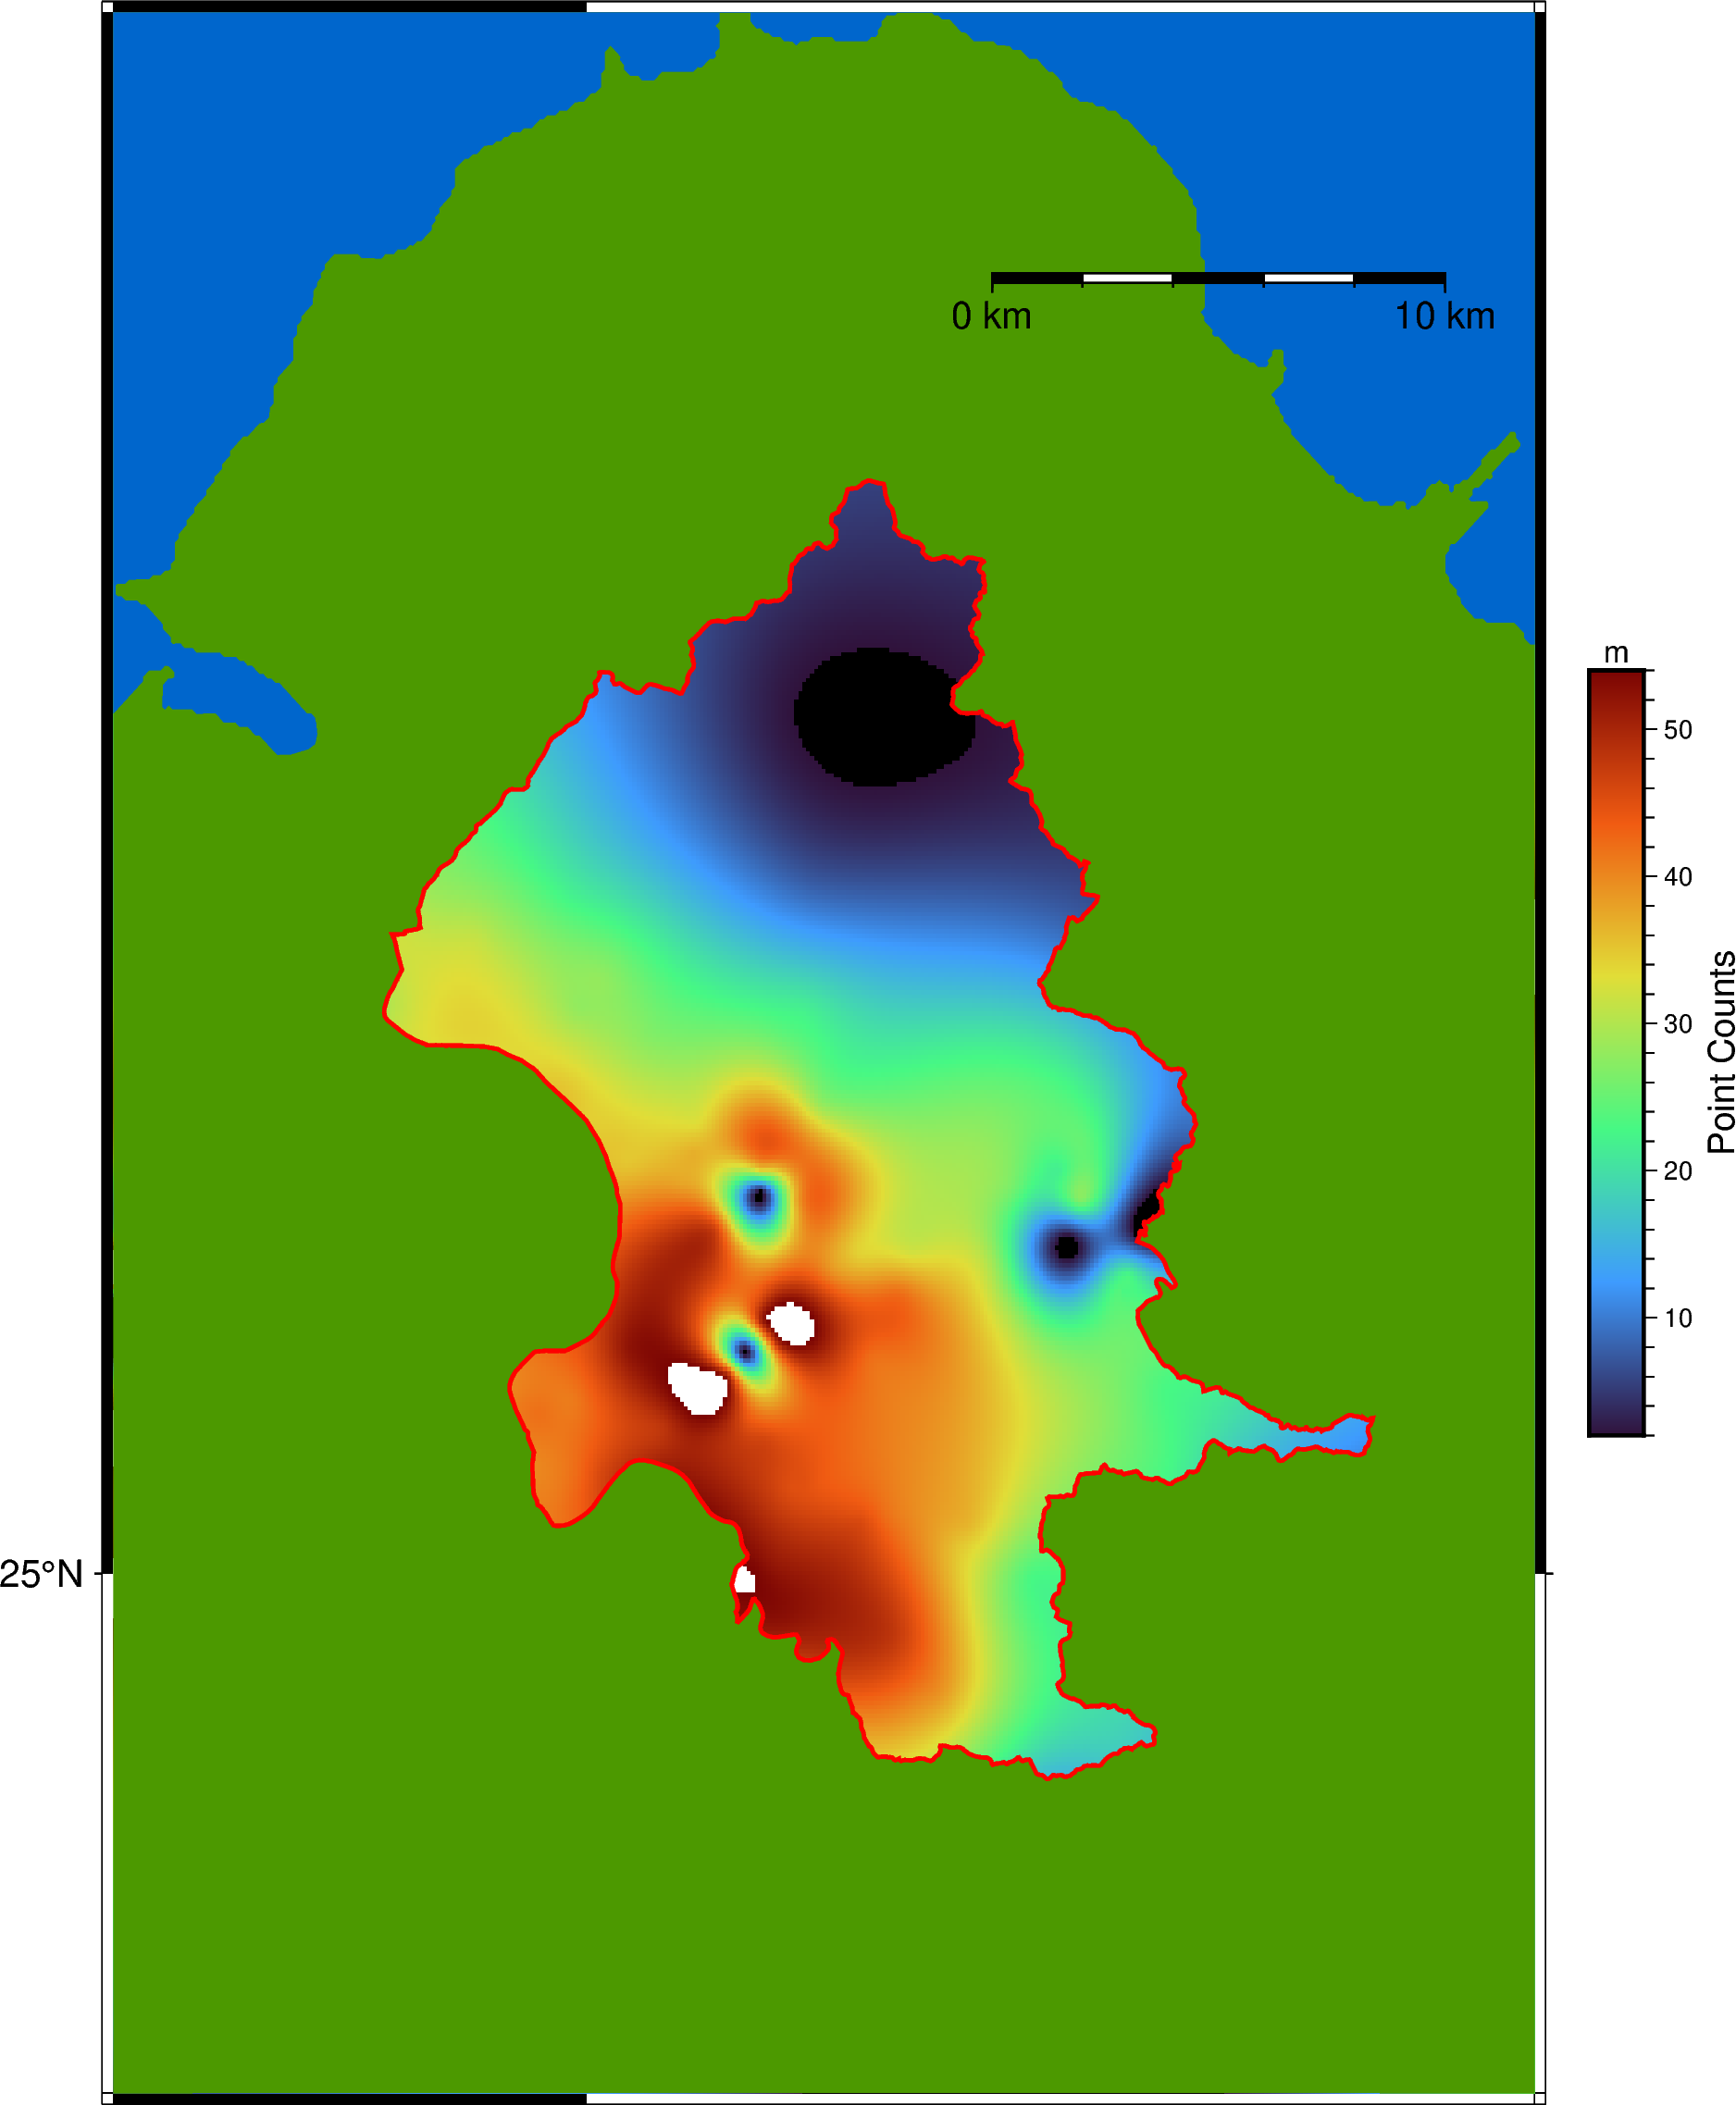

In [18]:
fig = pygmt.Figure()

min_val = taipei_count['Station_Count'].min()
max_val = taipei_count['Station_Count'].max()

pygmt.makecpt(cmap="turbo", 
              series=f"{min_val}/{max_val+round(np.log(max_val))}/{(max_val-min_val)/5}", 
              continuous=True,
              # log = True
             )

# fig.basemap(region = [118,122.5,21.5,26.5],
#             projection = 'M13c',
#             frame="a1f0.5g1",
#             verbose=True)

fig.basemap(region = [121.4,121.7,24.9,25.3],
            projection = 'M13c',
            frame="a1f0.5g1",
            verbose=True)

fig.grdimage(
    grid=grid,
    cmap=True, # 使用相同的 makecpt
)

fig.plot(
    data=mask_gdf, 
    fill="76/153/0",  # 填滿白色 (或 lightgray)
    # pen="0.5p,black" # 如果想要邊界有框線，可以加這行
)

fig.coast(resolution = "f",
          # borders=["1/0.5p,black", "2/0.5p,red", "3/0.5p,blue"],
          # shorelines= "0.5, black",
          water = "0/102/204",
          # land="76/153/0",
          map_scale = "f121:38/25:15/20/10+u"
)
#by gemini
#create colormap

# fig.plot(
#     data = gdf[['geometry','CBC', 'point_count', 'AVG_point', 'AVG_CBC']],# 這裡放你的 GeoDataFrame    # 【關鍵】指定要用哪一欄數值來決定顏色
#     aspatial = "Z=AVG_CBC",
#     cmap = True,                    # 【關鍵】告訴 PyGMT 使用剛剛 makecpt 做好的色標
#     # pen = '0.1p,red',
#     fill = '+z'                   # 【關鍵】"+z" 代表「依據 Z 值 (zvalue) 填色」
# )
fig.plot(
    data = taipei_outlines,
    pen = '1p,red',
)
# fig.plot(data = df[['Longitude', 'Latitude', 'Station_Count_10km']],
#         # zvalue = 'Station_Count_5km',
#         # x='Longitude', y = 'Latitude',
#         aspatial = 'Z=Station_Count_10km',
#         style = 'c0.1c',
#         cmap =True, 
#         # pen = '0.1p,black',
#         fill='+z',
#         transparency = 0)

fig.colorbar(
    frame=["x+lPoint Counts", "y+lm"], # x軸標籤, y軸單位
    position="JMR+o0.5c/0c+w7c/0.5c"   # 位置設定 (右側中間, 偏移, 長寬)
)

fig.savefig('Taipei_speedlimit_surface.png', dpi = 300,crop = '+m2c')

fig.show()